In [2]:
%load_ext autoreload

In [1]:
import numpy as np
import torch
from torch.utils.data import DataLoader
# from utils import evaluate, ScenarioWiseSampler
import os
from torch.utils.data import Subset
from model import DayCentModel
import random
import matplotlib.pyplot as plt
import os
from data import DayCentDataset

In [3]:
EXPERIMENT_ID = "experiment10"
PROCESSED_DIR = f"/projects/standard/kumarv/shared/dwij/daycent/data/{EXPERIMENT_ID}"
INPUT_NPY = f"/projects/standard/kumarv/shared/dwij/daycent/data/{EXPERIMENT_ID}/train_X.npy"
OUTPUT_NPY = f"/projects/standard/kumarv/shared/dwij/daycent/data/{EXPERIMENT_ID}/train_Y.npy"
INIT_COND = "/projects/standard/kumarv/shared/dwij/daycent/data/SAS_KGML_090925/InputData/initial_site_conditions.xlsx"
OUTPUT_DIR = f"/projects/standard/kumarv/shared/dwij/daycent/output/{EXPERIMENT_ID}"
PLOTS_DIR = f"/projects/standard/kumarv/shared/dwij/daycent/output/{EXPERIMENT_ID}/plots"
BATCH_SIZE = 2048
EPOCHS = 100
DEVICE = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")

In [4]:
# ----------------------
# Dataloader
# ----------------------
# check dataset
dataset = DayCentDataset(INPUT_NPY, OUTPUT_NPY, INIT_COND)
NUM_SCENARIOS = 50
UNIT_SIZE = int(len(dataset) / NUM_SCENARIOS)
train_size = int(UNIT_SIZE * (NUM_SCENARIOS * 0.7))
val_size = int(UNIT_SIZE * (NUM_SCENARIOS * 0.2))
test_size = int(UNIT_SIZE * (NUM_SCENARIOS * 0.1))

# 2) Create index arrays for each split
train_idx = np.arange(0, train_size)
val_idx = np.arange(train_size, train_size + val_size)
test_idx = np.arange(train_size + val_size, train_size + val_size + test_size)
all_idx = np.arange(0, train_size + val_size + test_size)                     

# 3) Wrap subsets
train_ds = Subset(dataset, train_idx)
val_ds   = Subset(dataset, val_idx)
test_ds  = Subset(dataset, test_idx)

# 4) Create loaders
all_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

print(f"Dataset sizes — total: {len(dataset)}, train: {len(train_ds)}, val: {len(val_ds)}, test: {len(test_ds)}")

Dataset sizes — total: 25500, train: 17850, val: 5100, test: 2550


In [5]:
# infer input dim
sample = dataset[0]
seq_feat_dim = sample["sequence"].shape[1]  # #features
init_dim = sample["init_cond"].shape[0]
year_dim = sample["year_enc"].shape[0]

print(f"Input feature dim: {seq_feat_dim}, init cond dim: {init_dim}, year enc dim: {year_dim}")


model = DayCentModel(input_dim=seq_feat_dim, init_dim=init_dim, year_dim=year_dim)
model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, "best_model.pth")))
model.to(DEVICE)

Input feature dim: 20, init cond dim: 245, year enc dim: 16


DayCentModel(
  (init_proj): Linear(in_features=261, out_features=32, bias=True)
  (daily_proj): Linear(in_features=20, out_features=32, bias=True)
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True)
  (somsc_attn): AttentionPooling(
    (attn): Linear(in_features=128, out_features=1, bias=True)
    (proj): Linear(in_features=128, out_features=128, bias=True)
  )
  (yield_attn): AttentionPooling(
    (attn): Linear(in_features=128, out_features=1, bias=True)
    (proj): Linear(in_features=128, out_features=128, bias=True)
  )
  (somsc_head): Linear(in_features=128, out_features=1, bias=True)
  (yield_head): Linear(in_features=128, out_features=1, bias=True)
)

In [16]:
all_preds = []
all_trues = []
all_masks = []

somsc_preds = []
somsc_trues = []
somsc_masks = []

for batch in all_loader:
    batch = {k: v.to(DEVICE) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
    with torch.no_grad():
        outputs = model(batch)

    all_preds.append(outputs['yield_pred'].cpu().numpy())
    all_trues.append(batch['yield'].cpu().numpy())
    all_masks.append(batch['yield_mask'].cpu().numpy())

    somsc_preds.append(outputs['somsc_pred'].cpu().numpy())
    somsc_trues.append(batch['somsc'].cpu().numpy())
    somsc_masks.append(batch['somsc_mask'].cpu().numpy())

# Concatenate all batches
pred_flat = np.concatenate(all_preds, axis=0)
true_flat = np.concatenate(all_trues, axis=0)
mask_flat = np.concatenate(all_masks, axis=0)

somsc_pred_flat = np.concatenate(somsc_preds, axis=0)
somsc_true_flat = np.concatenate(somsc_trues, axis=0)
somsc_mask_flat = np.concatenate(somsc_masks, axis=0)

In [17]:
print("SOMSC Predictions Stats:")
print(f"  Mean: {np.mean(somsc_pred_flat):.4f}, Std: {np.std(somsc_pred_flat):.4f}")
print(f"  Min: {np.min(somsc_pred_flat):.4f}, Max: {np.max(somsc_pred_flat):.4f}")

print(f"Length of somsc_pred_flat: {somsc_pred_flat.shape}")
print(f"Length of somsc_true_flat: {somsc_true_flat.shape}")
print(f"Length of yield_pred_flat: {pred_flat.shape}")

print("\nSOMSC True Stats:")
print(f"  Mean: {np.mean(somsc_true_flat):.4f}, Std: {np.std(somsc_true_flat):.4f}")
print(f"  Min: {np.min(somsc_true_flat):.4f}, Max: {np.max(somsc_true_flat):.4f}")

SOMSC Predictions Stats:
  Mean: -0.0688, Std: 1.0918
  Min: -2.7437, Max: 4.3830
Length of somsc_pred_flat: (25500, 12, 1)
Length of somsc_true_flat: (25500, 12)
Length of yield_pred_flat: (25500,)

SOMSC True Stats:
  Mean: 0.0000, Std: 0.9609
  Min: -3.5735, Max: 2.5807


In [18]:
import joblib
scaler_Y = joblib.load(os.path.join(PROCESSED_DIR, "scaler_Y_50.pkl"))
cgrain_mean = scaler_Y.mean_[1]
cgrain_scale = scaler_Y.scale_[1]

# Inverse transform manually for yield (1D arrays)
pred_flat = pred_flat * cgrain_scale + cgrain_mean
pred_flat = pred_flat * mask_flat
true_flat = true_flat * cgrain_scale + cgrain_mean
true_flat = true_flat * mask_flat

somsc_mean = scaler_Y.mean_[0]
somsc_scale = scaler_Y.scale_[0]

# somsc_pred_flat may have shape (N, T, 1) while somsc_mask_flat is (N, T).
# Squeeze the last dim if present so shapes match before masking.
if somsc_pred_flat.ndim == 3 and somsc_pred_flat.shape[2] == 1:
	somsc_pred_flat = somsc_pred_flat.squeeze(-1)

somsc_pred_flat = somsc_pred_flat * somsc_scale + somsc_mean
somsc_pred_flat = somsc_pred_flat * somsc_mask_flat

# Ensure somsc_true_flat has compatible shape as well
if somsc_true_flat.ndim == 3 and somsc_true_flat.shape[2] == 1:
	somsc_true_flat = somsc_true_flat.squeeze(-1)

somsc_true_flat = somsc_true_flat * somsc_scale + somsc_mean
somsc_true_flat = somsc_true_flat * somsc_mask_flat


In [19]:
class ScenarioWiseSampler:
    def __init__(self, input_path: str, indices):
        data_dict = np.load(input_path, allow_pickle=True).item()
        self.data = data_dict["data"]      # (N, 365, #features)
        self.mapping = data_dict["mapping"][indices]  # (N, 3) => (scenario, point_id, year)
        self.columns = list(data_dict["columns"])

    def get_year_indices(self, sid, pid):
        # get indices for all years for a given scenario id and plot id
        mask = (self.mapping[:, 0] == sid) & (self.mapping[:, 2] == pid)
        return np.where(mask)[0]
    
    def __iter__(self):
        for sid, year, pid in self.mapping:
            yield sid, year, pid

    def get_all_unique_pids(self):
        return np.unique(self.mapping[:, 2])

    def get_all_unique_years(self):
        return np.unique(self.mapping[:, 1])

    def get_all_unique_scenarios(self):
        unique_scenarios = np.unique(self.mapping[:, 0])
        print("Unique Scenarios in the sampler:")
        for scenario in unique_scenarios:
            print(scenario)
        return unique_scenarios

    def __len__(self) -> int:
        return len(self.mapping)

all_sampler = ScenarioWiseSampler(INPUT_NPY, all_idx)
train_sampler = ScenarioWiseSampler(INPUT_NPY, train_idx)
test_sampler = ScenarioWiseSampler(INPUT_NPY, test_idx)
val_sampler = ScenarioWiseSampler(INPUT_NPY, val_idx)

In [20]:
sids = all_sampler.get_all_unique_scenarios()
pids = all_sampler.get_all_unique_pids()
yids = all_sampler.get_all_unique_years()

print(f"Total scenarios: {len(sids)}, Total plots: {len(pids)}, Total years: {len(yids)}")
print("Unique point IDs:")
print(pids)
print("Unique Year IDs:")
print(yids)

Unique Scenarios in the sampler:
scenario_1000
scenario_1099
scenario_1390
scenario_1616
scenario_2034
scenario_2600
scenario_2729
scenario_3503
scenario_3932
scenario_4880
Total scenarios: 10, Total plots: 102, Total years: 25
Unique point IDs:
['1773513' '1773749' '1773883' '1774528' '1774685' '1774853' '1775042'
 '1776558' '1776592' '1777257' '1777271' '1778109' '1778253' '1779437'
 '1779518' '1779588' '1782812' '1784153' '1784216' '1789230' '1790161'
 '1790233' '1790935' '1794265' '1794644' '1795246' '1795304' '1796415'
 '1798503' '657271' '657277' '657532' '657791' '658349' '659118' '659143'
 '659172' '661129' '661514' '663385' '664407' '664432' '664552' '664763'
 '665320' '666125' '667689' '668968' '669194' '669561' '669606' '669797'
 '670226' '670405' '670931' '671294' '672163' '674884' '675099' '675631'
 '676905' '677234' '678080' '678248' '678676' '679163' '679545' '680247'
 '681419' '681627' '681794' '682280' '683527' '684108' '684585' '684591'
 '685292' '685391' '685970' '68

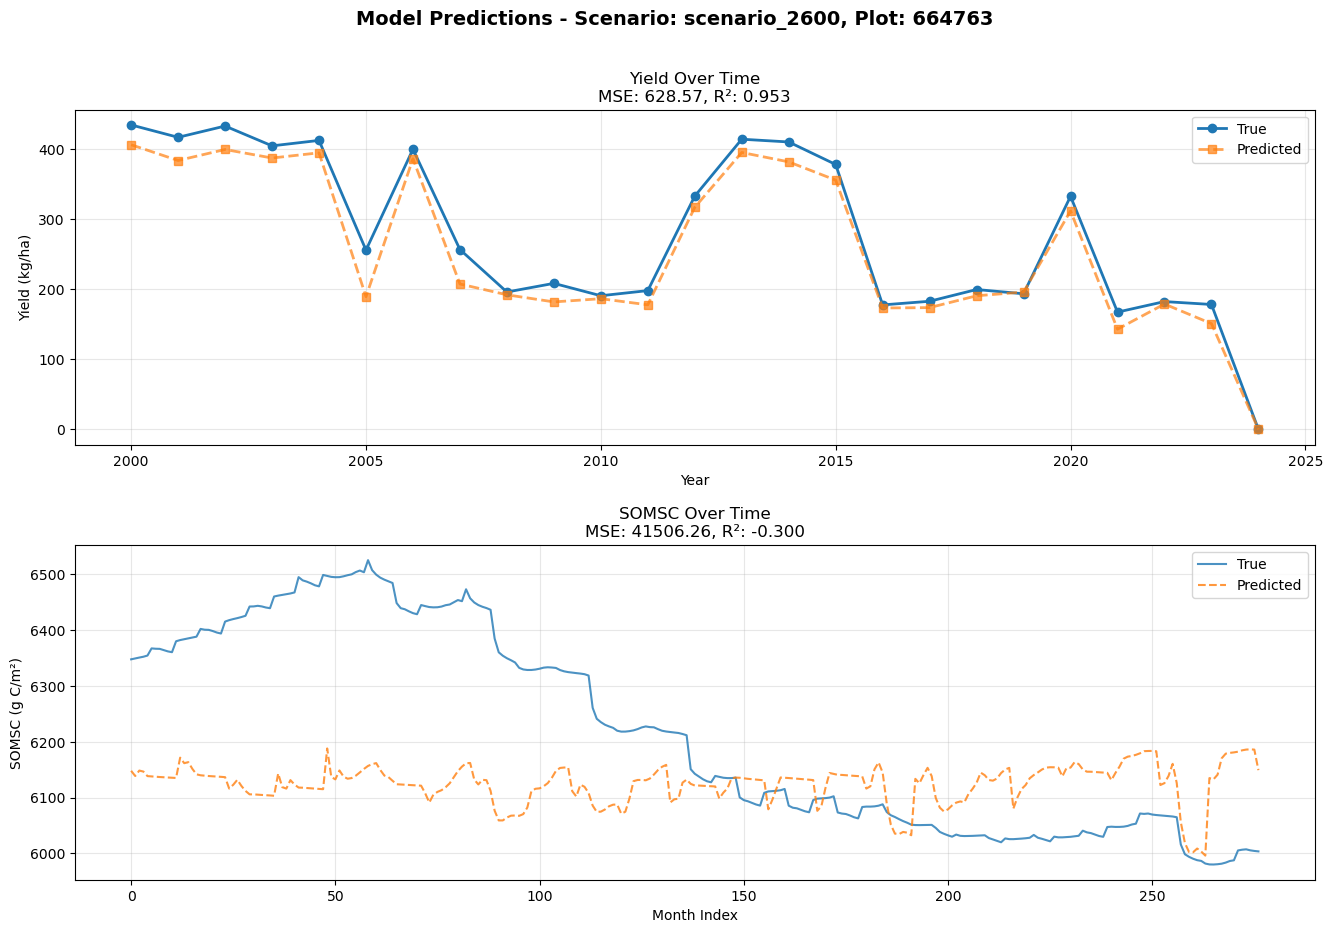

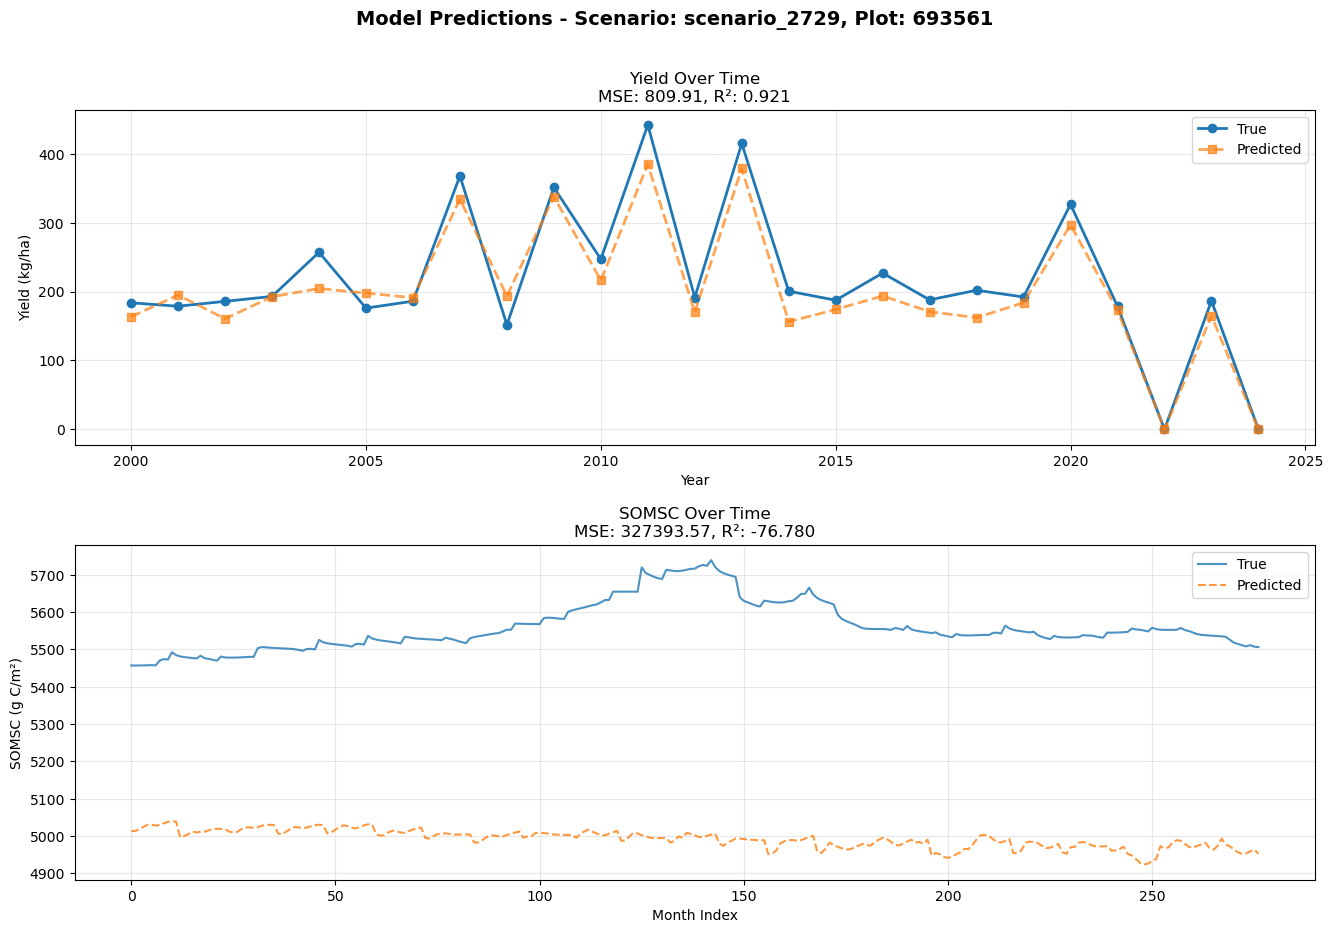

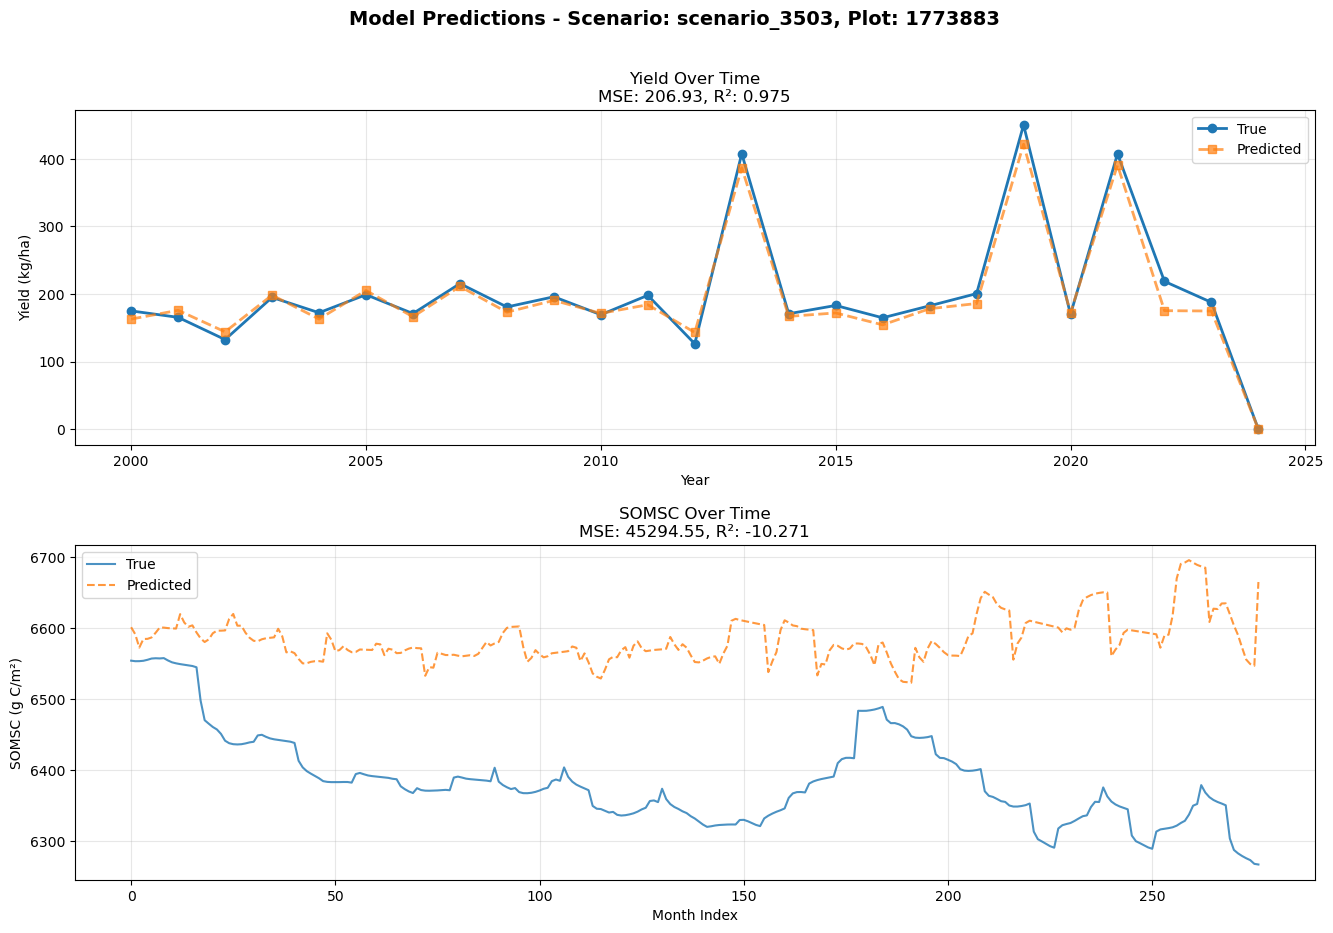

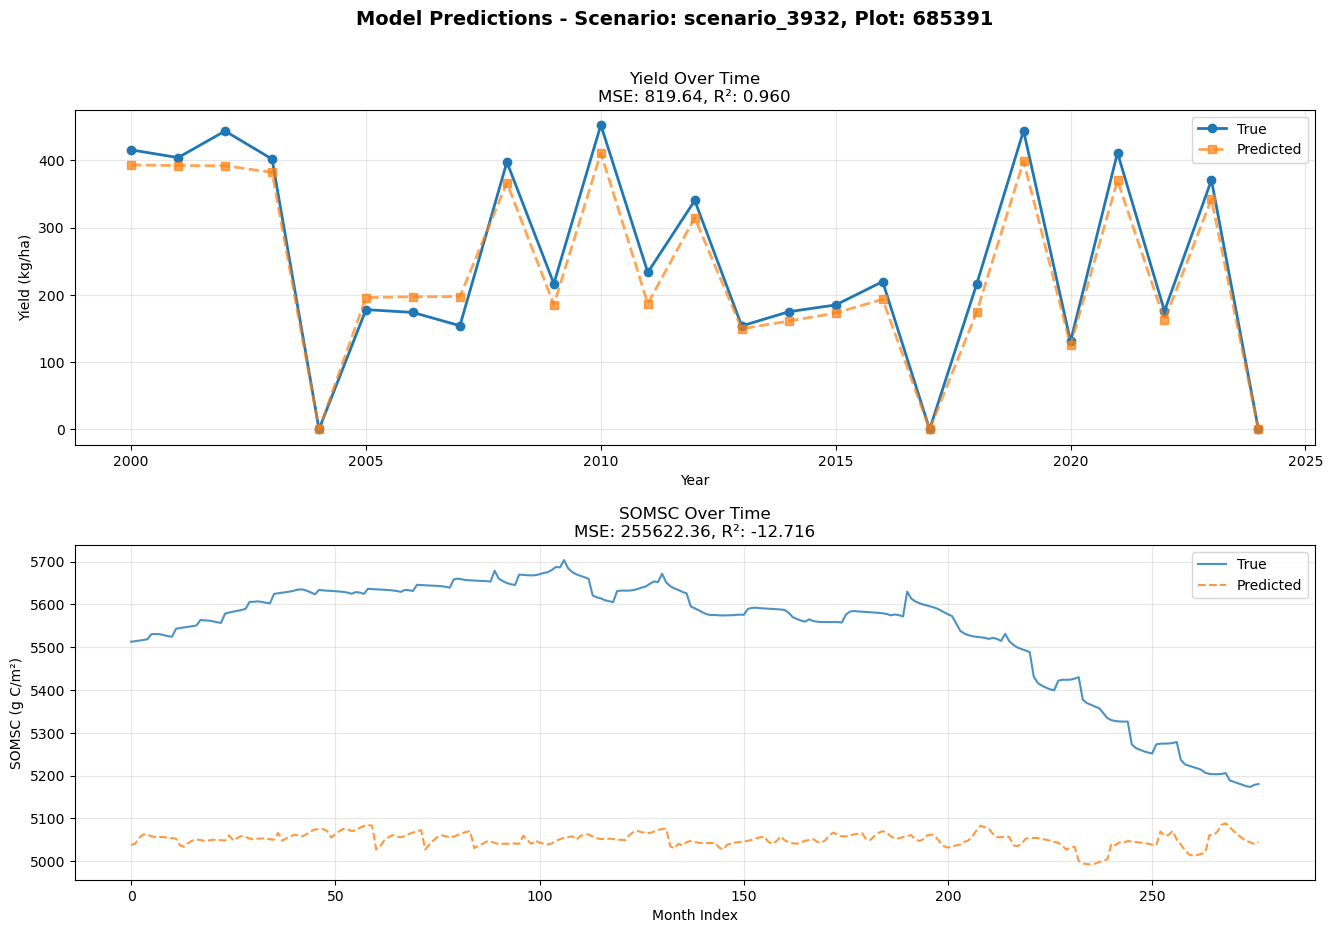

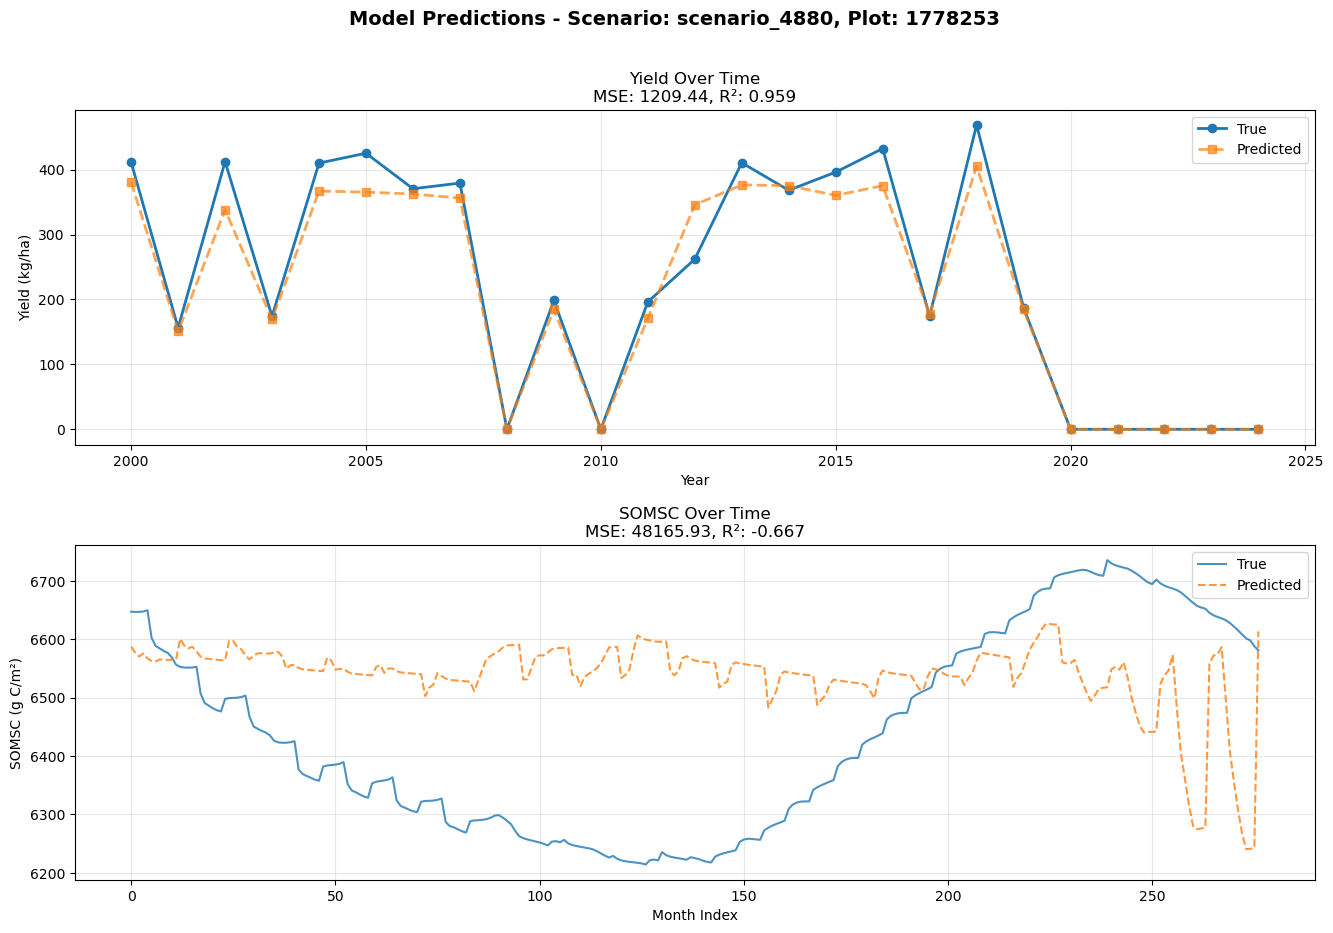

In [28]:
def plot_predictions(sid, pid, year_indices, pred_flat, true_flat, mask_flat, 
                     somsc_pred_flat, somsc_true_flat, somsc_mask_flat, plots_dir):
    """Plot yield and SOMSC predictions with normalized scales."""
    # Extract and mask yield data
    pred_yield = (pred_flat * mask_flat)[year_indices]
    true_yield = true_flat[year_indices]
    
    # Extract and mask SOMSC data
    somsc_pred = (somsc_pred_flat[year_indices] * somsc_mask_flat[year_indices]).flatten()
    somsc_true = (somsc_true_flat[year_indices] * somsc_mask_flat[year_indices]).flatten()
    
    # Filter non-zero SOMSC values
    nonzero_mask = somsc_mask_flat[year_indices].flatten() > 0
    somsc_pred = somsc_pred[nonzero_mask]
    somsc_true = somsc_true[nonzero_mask]
    
    # Calculate metrics
    yield_mse = np.mean((pred_yield - true_yield)**2)
    yield_r2 = 1 - (np.sum((true_yield - pred_yield)**2) / np.sum((true_yield - np.mean(true_yield))**2))
    somsc_mse = np.mean((somsc_pred - somsc_true)**2)
    somsc_r2 = 1 - (np.sum((somsc_true - somsc_pred)**2) / np.sum((somsc_true - np.mean(somsc_true))**2))
    
    # Create figure with 4 subplots
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(2, 1, hspace=0.3, wspace=0.3)
    
    # 1. Yield time series
    ax1 = fig.add_subplot(gs[0, 0])
    years = np.arange(2000, 2000 + len(pred_yield))
    ax1.plot(years, true_yield, 'o-', label='True', linewidth=2, markersize=6)
    ax1.plot(years, pred_yield, 's--', label='Predicted', linewidth=2, markersize=6, alpha=0.7)
    ax1.set_title(f'Yield Over Time\nMSE: {yield_mse:.2f}, R²: {yield_r2:.3f}')
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Yield (kg/ha)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 3. SOMSC time series
    ax3 = fig.add_subplot(gs[1, 0])
    months = np.arange(len(somsc_pred))
    ax3.plot(months, somsc_true, '-', label='True', linewidth=1.5, alpha=0.8)
    ax3.plot(months, somsc_pred, '--', label='Predicted', linewidth=1.5, alpha=0.8)
    ax3.set_title(f'SOMSC Over Time\nMSE: {somsc_mse:.2f}, R²: {somsc_r2:.3f}')
    ax3.set_xlabel('Month Index')
    ax3.set_ylabel('SOMSC (g C/m²)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    fig.suptitle(f'Model Predictions - Scenario: {sid}, Plot: {pid}', fontsize=14, fontweight='bold')
    # plt.savefig(os.path.join(plots_dir, sid, f'plot_{pid}.png'), dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

# Generate plots for last 5 scenarios
for sid in sids[-5:]:
    plot_dir = os.path.join(PLOTS_DIR, sid)
    os.makedirs(plot_dir, exist_ok=True)
    
    random_pids = random.sample(list(pids), min(5, len(pids)))
    for pid in random_pids:
        year_indices = all_sampler.get_year_indices(sid, pid)
        plot_predictions(sid, pid, year_indices, pred_flat, true_flat, mask_flat,
                        somsc_pred_flat, somsc_true_flat, somsc_mask_flat, PLOTS_DIR)
        break  # Plot only first random pid per scenario